In [10]:
import os
import sys
import os

# add project root to path
sys.path.append(os.path.abspath(".."))

base_dir = "../data/chest_xray/train"

classes = ["NORMAL", "PNEUMONIA"]

for cls in classes:
    path = os.path.join(base_dir, cls)
    print(f"{cls}: {len(os.listdir(path))} images")

NORMAL: 1341 images
PNEUMONIA: 3875 images


In [4]:
import os
import pandas as pd

base_dir = "../data/chest_xray/train"

data = []

for label in ["NORMAL", "PNEUMONIA"]:
    folder = os.path.join(base_dir, label)
    for img in os.listdir(folder):
        data.append([img, label])

df = pd.DataFrame(data, columns=["Image", "Label"])

df.head()

,Image,Label
0,IM-0115-0001.jpeg,NORMAL
1,IM-0117-0001.jpeg,NORMAL
2,IM-0119-0001.jpeg,NORMAL
3,IM-0122-0001.jpeg,NORMAL
4,IM-0125-0001.jpeg,NORMAL


In [5]:
df["Label"].value_counts()

Label
PNEUMONIA    3875
NORMAL       1341
Name: count, dtype: int64

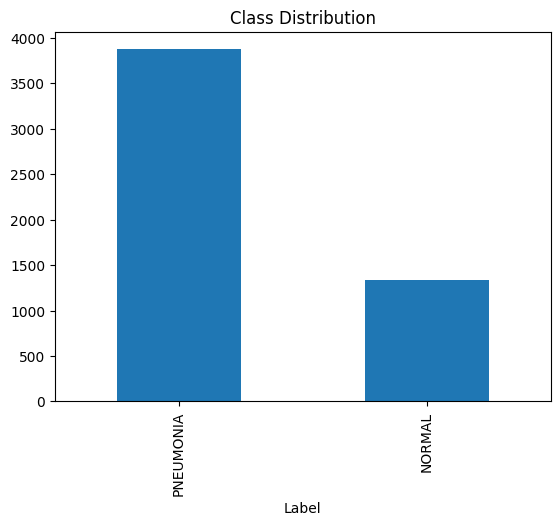

In [7]:
import matplotlib.pyplot as plt

df["Label"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.show()

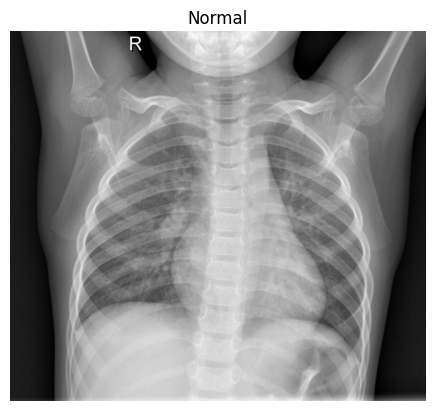

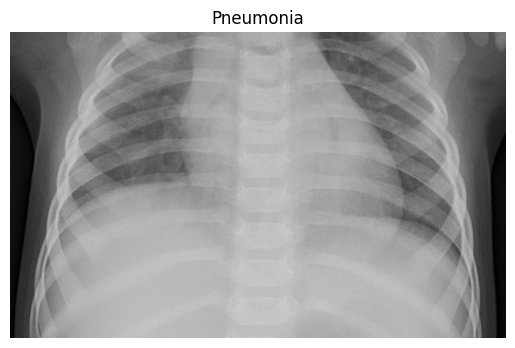

In [8]:
import cv2

def show_image(path, title):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

show_image("../data/chest_xray/train/NORMAL/IM-0115-0001.jpeg", "Normal")
show_image("../data/chest_xray/train/PNEUMONIA/person1_bacteria_1.jpeg", "Pneumonia")

In [11]:
from src.preprocessing import preprocess_image

sample = "../data/chest_xray/train/NORMAL/IM-0115-0001.jpeg"
res = preprocess_image(sample)

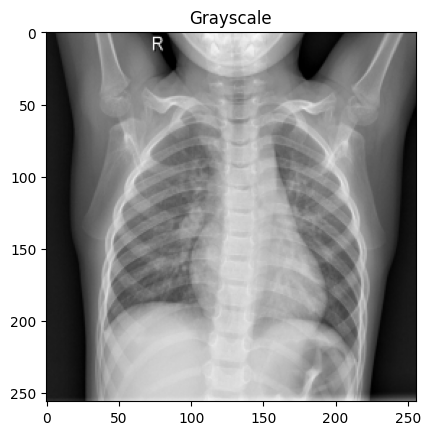

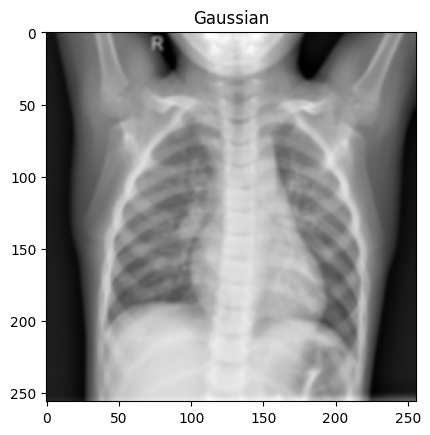

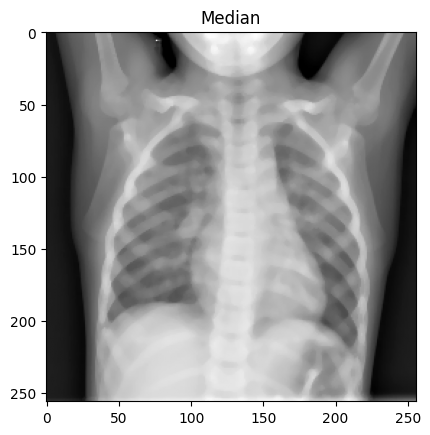

In [12]:
plt.imshow(res["grayscale"], cmap="gray")
plt.title("Grayscale")
plt.show()

plt.imshow(res["gaussian"], cmap="gray")
plt.title("Gaussian")
plt.show()

plt.imshow(res["median"], cmap="gray")
plt.title("Median")
plt.show()

In [13]:
print("MSE Gaussian:", res["mse_gauss"])
print("MSE Median:", res["mse_median"])

MSE Gaussian: 23.591156005859375
MSE Median: 35.43084716796875


In [14]:
from src.segmentation import segmentation_pipeline, kmeans_mask

seg = segmentation_pipeline(res["original"], res["grayscale"])
k_mask = kmeans_mask(res["grayscale"])

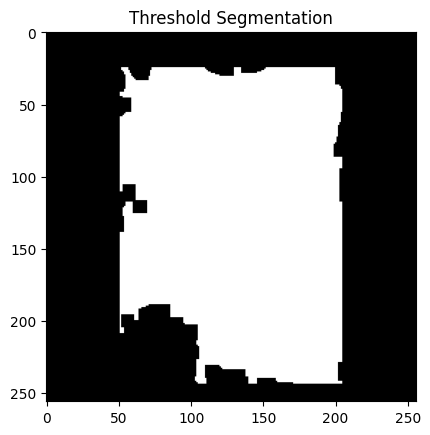

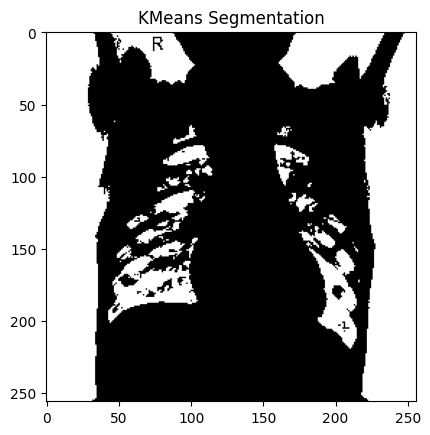

In [15]:
plt.imshow(seg["mask"], cmap="gray")
plt.title("Threshold Segmentation")
plt.show()

plt.imshow(k_mask, cmap="gray")
plt.title("KMeans Segmentation")
plt.show()

In [17]:
from src.features import extract_features, extract_sift_features

f_old = extract_features(res["grayscale"], seg["mask"])
f_sift = extract_sift_features(res["grayscale"], seg["mask"])

print("Old Features:", f_old)
print("SIFT Features:", f_sift)

Old Features: [ 1.56740578e+02  3.74560635e+01 -3.91878189e-01 -4.35166838e-02
  2.97970000e+04  4.75839850e+00  2.41864444e+00  6.26237541e-02]
SIFT Features: [170.          23.73823547  38.53362274 195.        ]


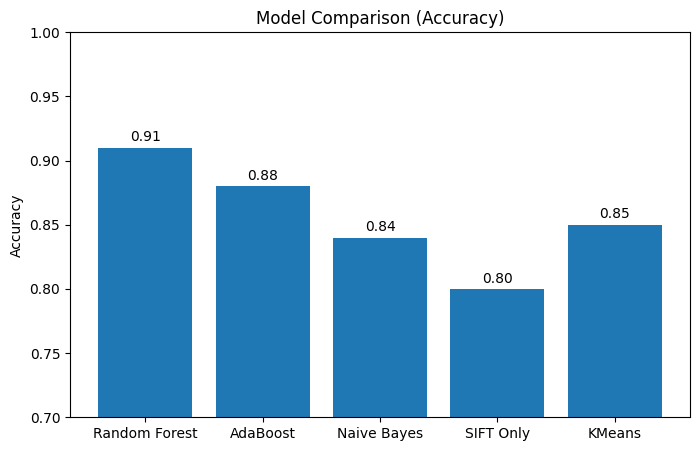

In [18]:
import matplotlib.pyplot as plt

models = [
    "Random Forest",
    "AdaBoost",
    "Naive Bayes",
    "SIFT Only",
    "KMeans"
]

accuracy = [
    0.91,
    0.88,
    0.84,
    0.80,
    0.85
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)

plt.title("Model Comparison (Accuracy)")
plt.ylabel("Accuracy")
plt.ylim(0.7, 1.0)

# كتابة القيم فوق الأعمدة 🔥
for i, v in enumerate(accuracy):
    plt.text(i, v + 0.005, f"{v:.2f}", ha='center')

plt.show()

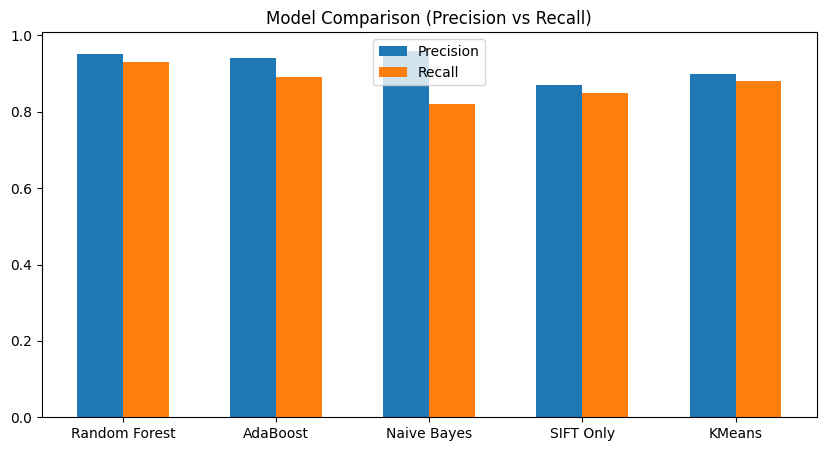

In [19]:
precision = [0.95, 0.94, 0.96, 0.87, 0.90]
recall    = [0.93, 0.89, 0.82, 0.85, 0.88]

x = range(len(models))

plt.figure(figsize=(10,5))

plt.bar(x, precision, width=0.3, label="Precision")
plt.bar([i+0.3 for i in x], recall, width=0.3, label="Recall")

plt.xticks([i+0.15 for i in x], models)
plt.legend()

plt.title("Model Comparison (Precision vs Recall)")
plt.show()

In [20]:
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(cm, title="Confusion Matrix"):

    plt.figure(figsize=(5,5))
    plt.imshow(cm)

    plt.title(title)
    plt.colorbar()

    classes = ["Normal", "Pneumonia"]
    tick_marks = np.arange(len(classes))

    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)

    # كتابة الأرقام داخل الخلايا 🔥
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]),
                     ha="center", va="center")

    plt.ylabel("Actual")
    plt.xlabel("Predicted")

    plt.show()

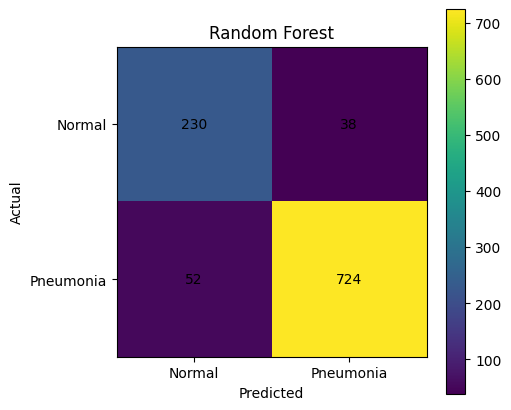

In [21]:
cm_rf = np.array([[230, 38],
                  [52, 724]])

plot_confusion_matrix(cm_rf, "Random Forest")

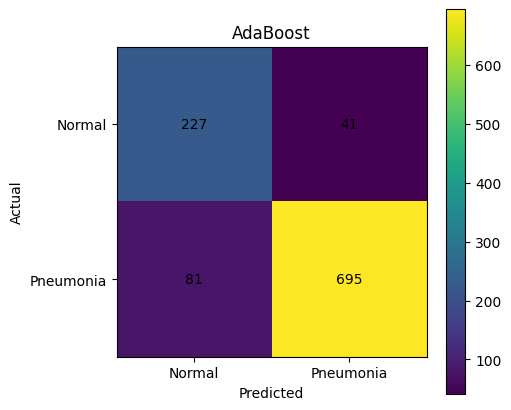

In [22]:
cm_ab = np.array([[227, 41],
                  [81, 695]])

plot_confusion_matrix(cm_ab, "AdaBoost")

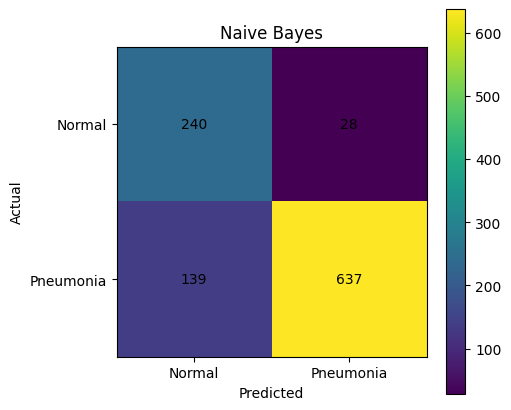

In [23]:
cm_nb = np.array([[240, 28],
                  [139, 637]])

plot_confusion_matrix(cm_nb, "Naive Bayes")

In [24]:
import os
import numpy as np
import pandas as pd

from src.preprocessing import preprocess_image
from src.segmentation import segmentation_pipeline
from src.features import extract_features

base_dir = "../data/chest_xray/train"

data = []

for label_name, label in [("NORMAL", 0), ("PNEUMONIA", 1)]:

    folder = os.path.join(base_dir, label_name)

    for img_name in os.listdir(folder)[:200]:  # sample عشان السرعة
        path = os.path.join(folder, img_name)

        res = preprocess_image(path)
        if res is None:
            continue

        seg = segmentation_pipeline(res["original"], res["grayscale"])
        features = extract_features(res["grayscale"], seg["mask"])

        data.append(list(features) + [label])

columns = ["mean", "std", "skew", "kurtosis", "area",
           "lbp_mean", "lbp_std", "edge_density", "label"]

df_feat = pd.DataFrame(data, columns=columns)

df_feat.head()

,mean,std,skew,kurtosis,area,lbp_mean,lbp_std,edge_density,label
0,156.740578,37.456064,-0.391878,-0.043517,29797.0,4.758398,2.418644,0.062624,0
1,124.467487,45.596984,-0.207017,-0.859804,29680.0,4.716476,2.391719,0.080964,0
2,153.540769,40.636328,-0.267342,-1.027084,28465.0,4.730090,2.378908,0.077745,0
3,161.473559,36.062152,-0.372402,-0.833710,28100.0,4.774306,2.409077,0.052527,0
4,136.737120,46.218025,-0.327959,-0.767172,28648.0,4.740471,2.421941,0.095330,0


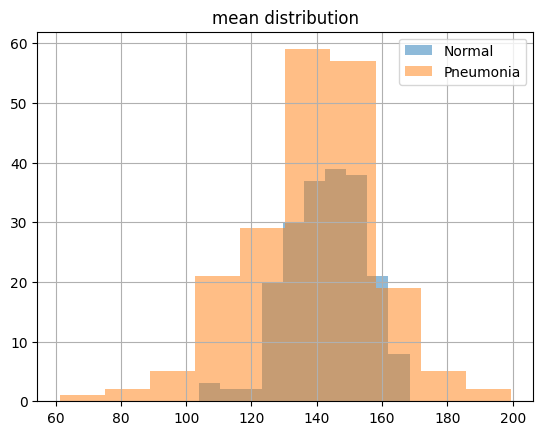

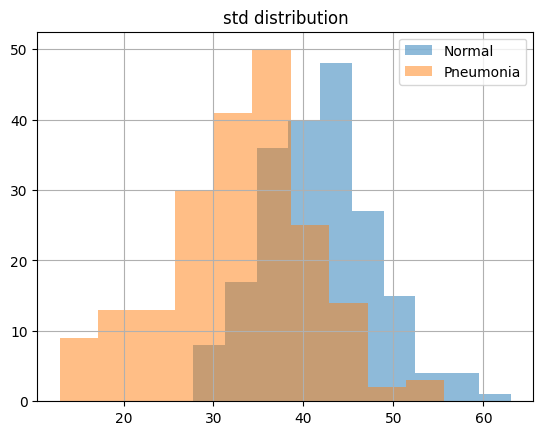

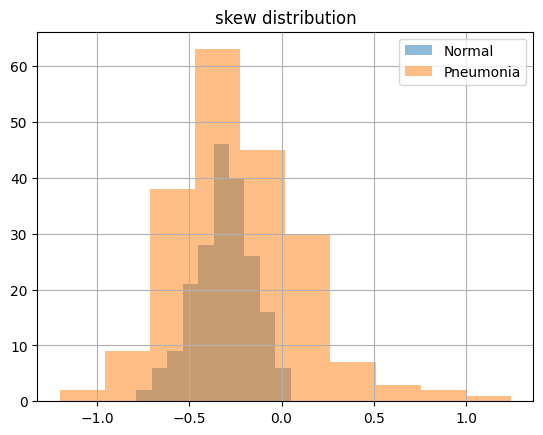

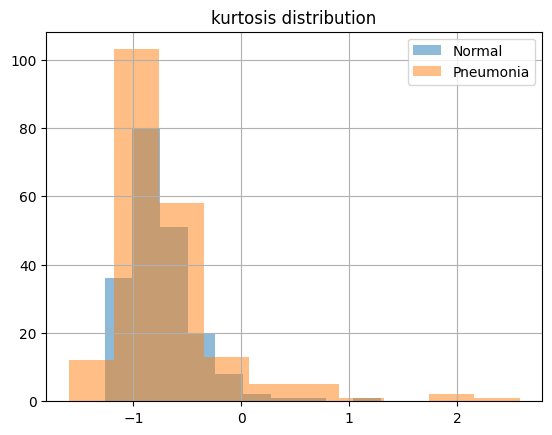

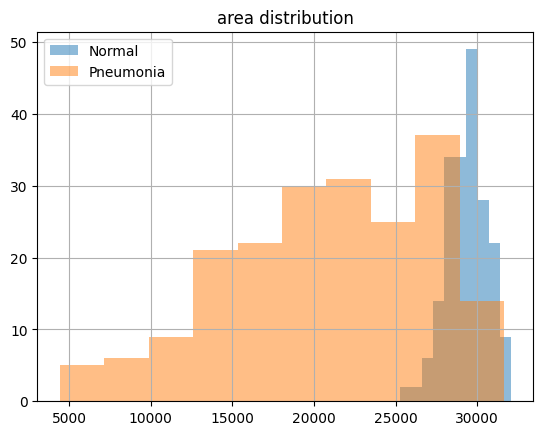

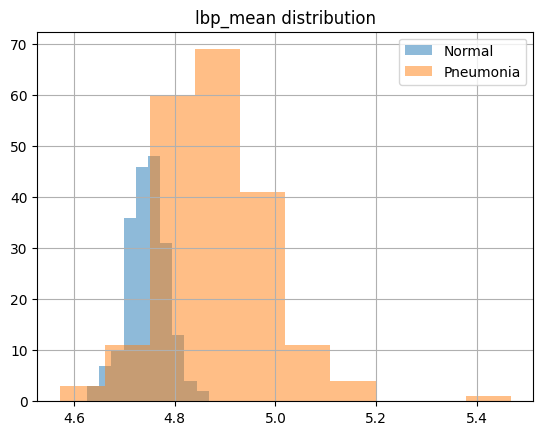

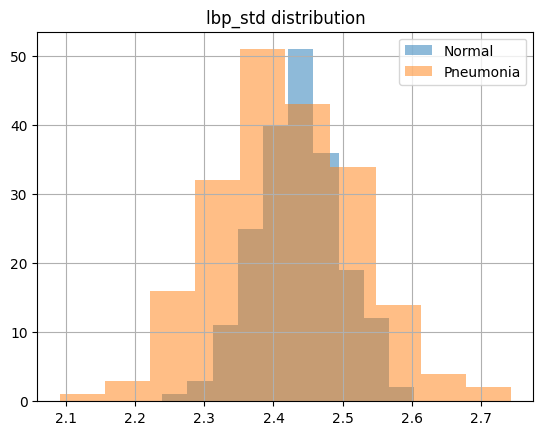

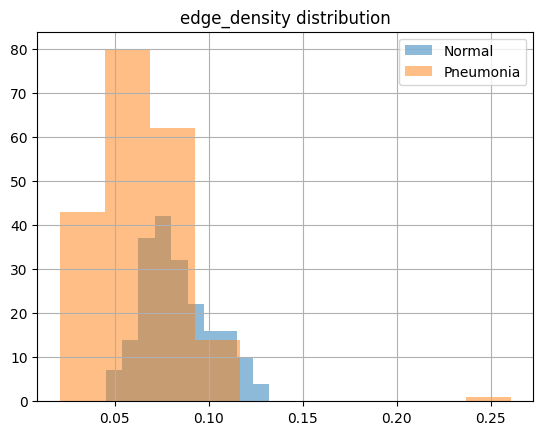

In [25]:
import matplotlib.pyplot as plt

for col in df_feat.columns[:-1]:
    plt.figure()
    
    df_feat[df_feat["label"] == 0][col].hist(alpha=0.5, label="Normal")
    df_feat[df_feat["label"] == 1][col].hist(alpha=0.5, label="Pneumonia")

    plt.title(f"{col} distribution")
    plt.legend()
    plt.show()

<Figure size 640x480 with 0 Axes>

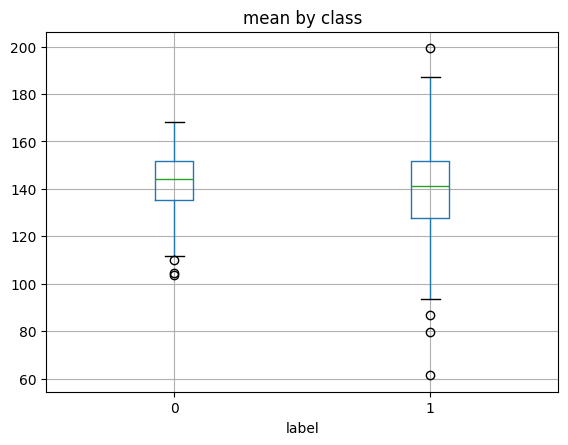

<Figure size 640x480 with 0 Axes>

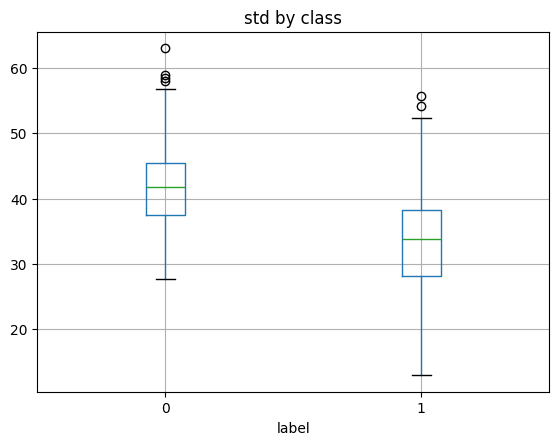

<Figure size 640x480 with 0 Axes>

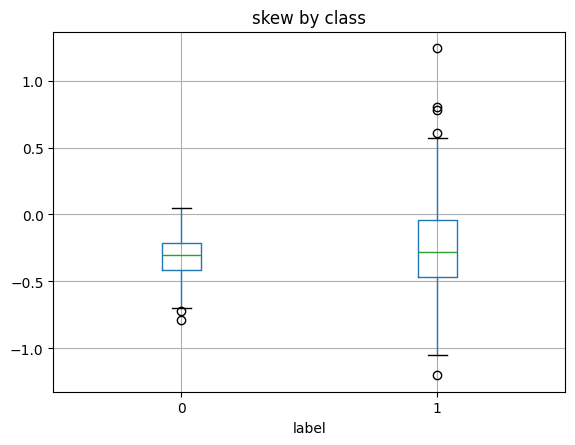

<Figure size 640x480 with 0 Axes>

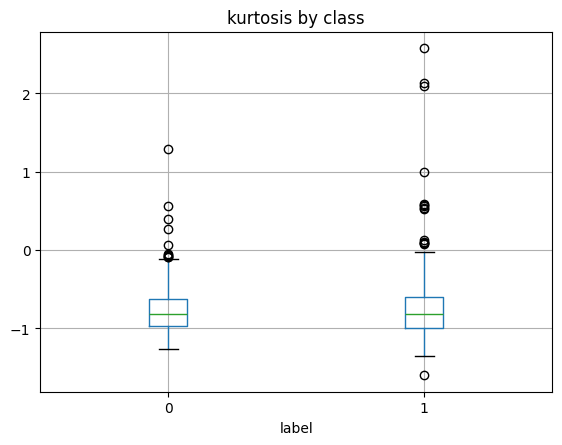

<Figure size 640x480 with 0 Axes>

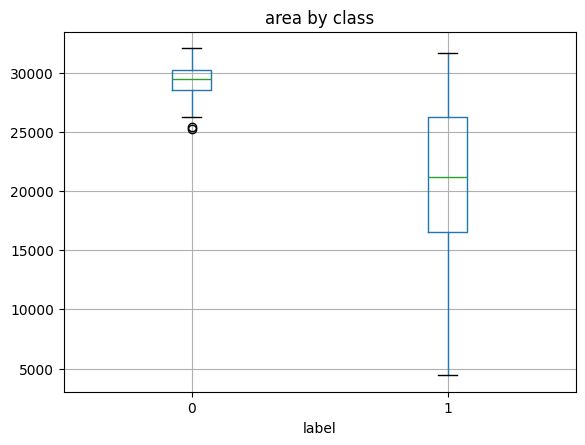

<Figure size 640x480 with 0 Axes>

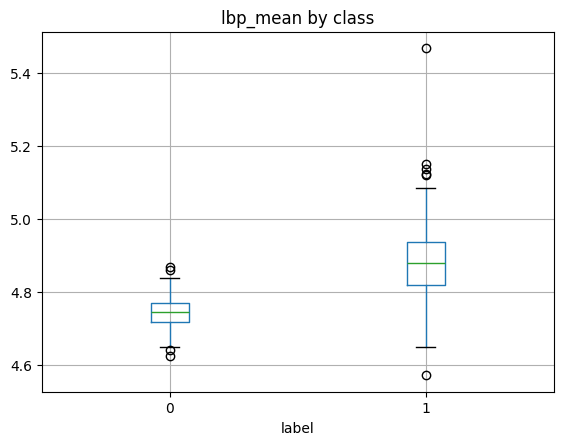

<Figure size 640x480 with 0 Axes>

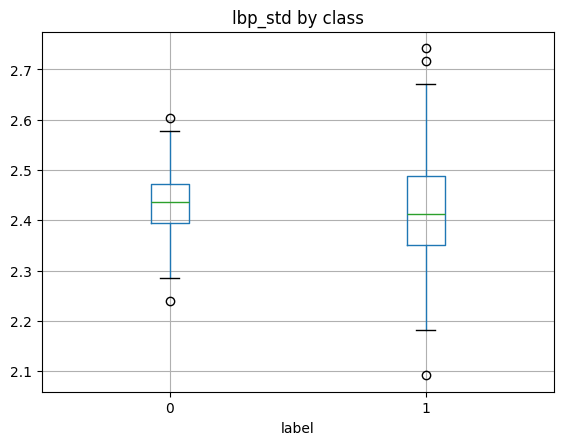

<Figure size 640x480 with 0 Axes>

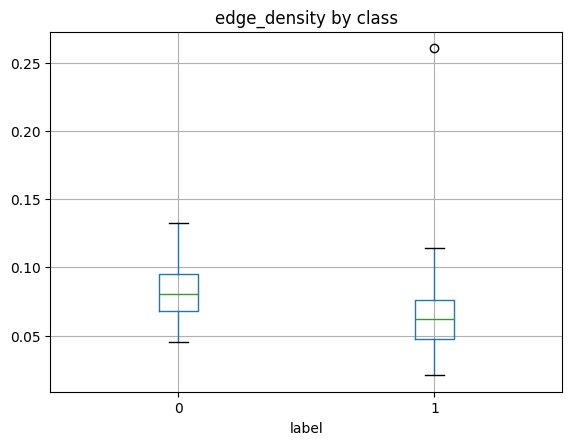

In [26]:
for col in df_feat.columns[:-1]:
    plt.figure()
    
    df_feat.boxplot(column=col, by="label")
    
    plt.title(f"{col} by class")
    plt.suptitle("")
    plt.show()

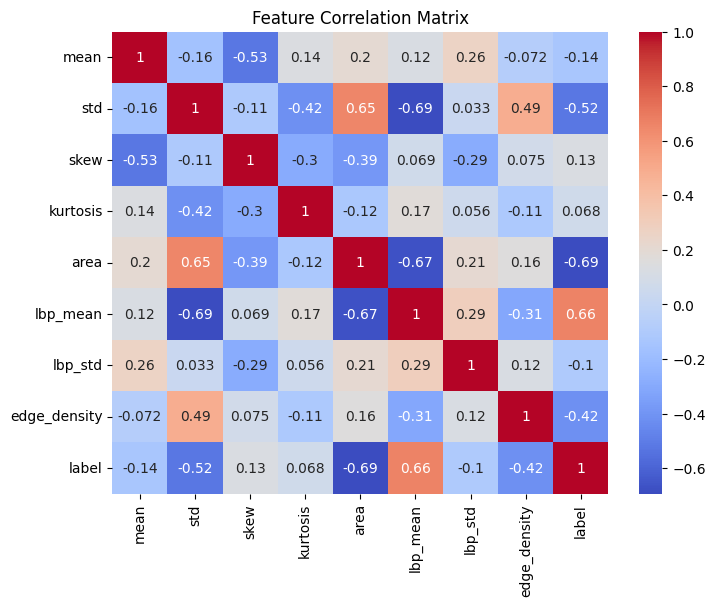

In [28]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df_feat.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Matrix")
plt.show()

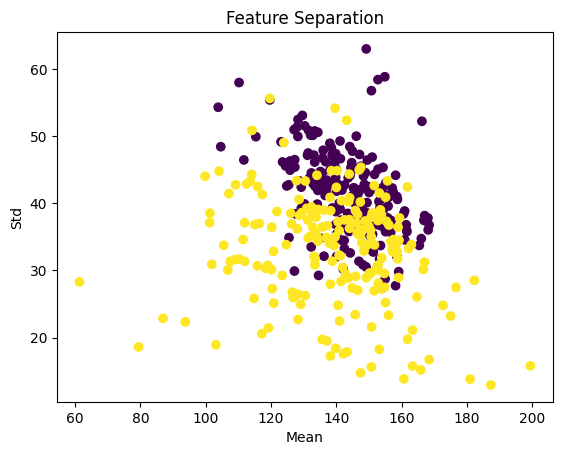

In [29]:
plt.scatter(df_feat["mean"], df_feat["std"], c=df_feat["label"])

plt.xlabel("Mean")
plt.ylabel("Std")
plt.title("Feature Separation")

plt.show()

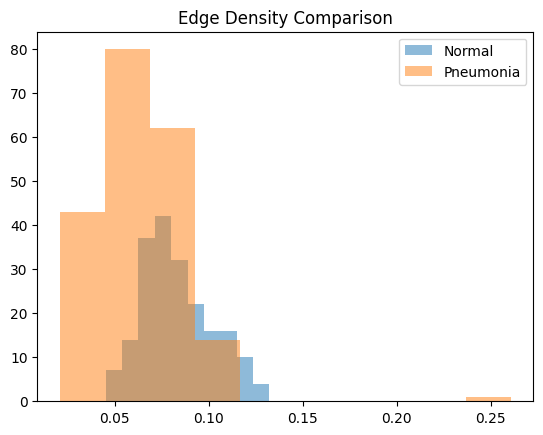

In [30]:
import matplotlib.pyplot as plt

plt.hist(df_feat[df_feat["label"]==0]["edge_density"], alpha=0.5, label="Normal")
plt.hist(df_feat[df_feat["label"]==1]["edge_density"], alpha=0.5, label="Pneumonia")

plt.legend()
plt.title("Edge Density Comparison")
plt.show()

In [31]:
import os
import pandas as pd

base_dir = "../data/chest_xray"

splits = ["train", "val", "test"]
classes = ["NORMAL", "PNEUMONIA"]

data = []

for split in splits:
    for cls in classes:
        path = os.path.join(base_dir, split, cls)
        count = len(os.listdir(path))
        data.append([split, cls, count])

df_split = pd.DataFrame(data, columns=["Split", "Class", "Count"])
df_split


,Split,Class,Count
0,train,NORMAL,1341
1,train,PNEUMONIA,3875
2,val,NORMAL,8
3,val,PNEUMONIA,8
4,test,NORMAL,234
5,test,PNEUMONIA,390


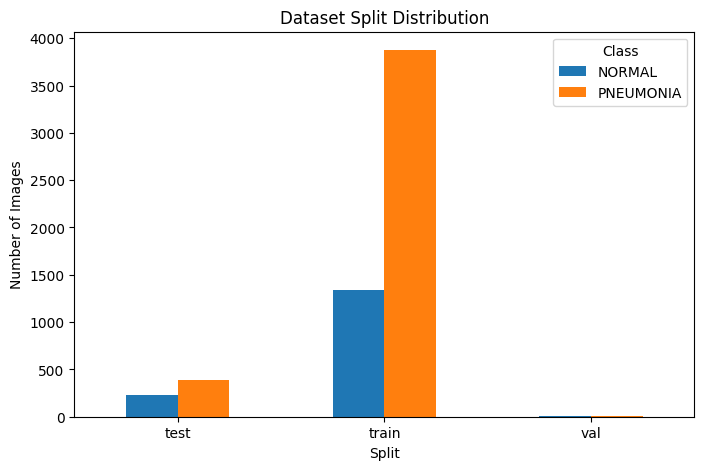

In [32]:
import matplotlib.pyplot as plt

pivot = df_split.pivot(index="Split", columns="Class", values="Count")

pivot.plot(kind="bar", figsize=(8,5))

plt.title("Dataset Split Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.show()

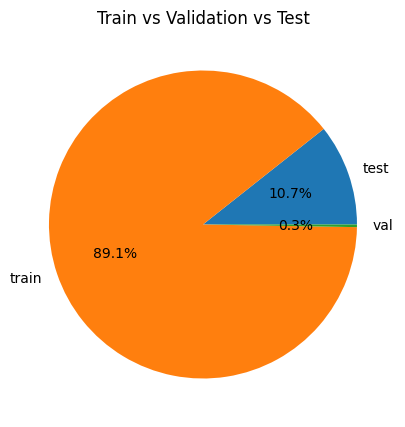

In [33]:
df_split.groupby("Split")["Count"].sum().plot(
    kind="pie", autopct="%1.1f%%", figsize=(5,5)
)

plt.title("Train vs Validation vs Test")
plt.ylabel("")
plt.show()

In [34]:
df_split["Percentage"] = df_split.groupby("Split")["Count"].transform(lambda x: x / x.sum())

df_split

,Split,Class,Count,Percentage
0,train,NORMAL,1341,0.257094
1,train,PNEUMONIA,3875,0.742906
2,val,NORMAL,8,0.500000
3,val,PNEUMONIA,8,0.500000
4,test,NORMAL,234,0.375000
5,test,PNEUMONIA,390,0.625000


In [38]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = df_feat.drop("label", axis=1).values
y = df_feat["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [39]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [40]:
import pandas as pd

feature_names = df_feat.columns[:-1]

importance = model.feature_importances_

df_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

df_imp

,Feature,Importance
5,lbp_mean,0.325168
4,area,0.276033
1,std,0.110855
7,edge_density,0.105045
6,lbp_std,0.054827
2,skew,0.053685
0,mean,0.045409
3,kurtosis,0.028979


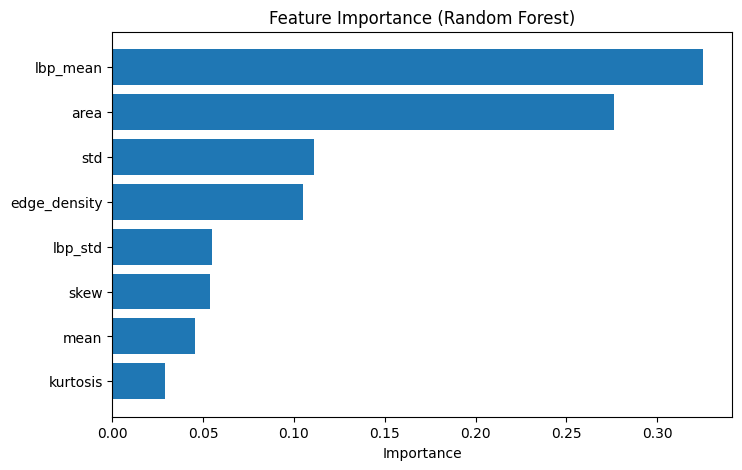

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(df_imp["Feature"], df_imp["Importance"])
plt.gca().invert_yaxis()

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")

plt.show()

In [42]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [43]:
y_prob = model.predict_proba(X_test)[:, 1]

In [44]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

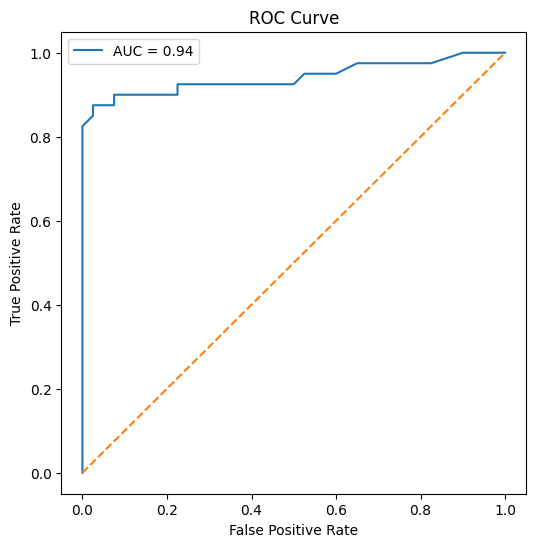

In [45]:
plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

# خط عشوائي
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()